# MLP 干预采样与 Reweight EI（RW-EI）的对照实验

本 notebook 检验两个问题：

1. **一致性**：MLP 拟合后干预采样与不拟合动力学的 Reweight EI（RW-EI），是否给出近似相同的 EI？
2. **正确性**：两种估计是否接近已知随机动力学在目标干预分布下的数值真值？

两条路径最终都使用同一个加权多项式三角传输映射（TM）互信息估计器，单位统一为 bit。这样将差异集中在“如何获得干预联合分布”，而不是信息量估计器本身。

## 1. 已知数据生成过程

令观测输入为 $\boldsymbol{X}_t=(X_{1,t},X_{2,t})^\top$。先生成高斯 copula 潜变量

$$
\boldsymbol{Z}_t\sim\mathcal N\!\left(\boldsymbol{0},\begin{bmatrix}1&\rho\\\rho&1\end{bmatrix}\right),\qquad X_{j,t}=2\Phi(Z_{j,t})-1.
$$

因此每个 $X_{j,t}$ 的边缘分布都是 $\operatorname{Unif}[-1,1]$，但当 $\rho\neq0$ 时两者在观测分布 $p_{\mathrm{obs}}(\boldsymbol{x})$ 下相关。已知的非线性随机动力学为

$$
Y_{t+1}=f(\boldsymbol{X}_t)+\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,\sigma^2),
$$

$$
f(\boldsymbol{x})=0.8x_1-0.4x_2+1.1\sin(\pi x_1x_2)+0.35x_1^2.
$$

这里没有线性动力学假设；唯一固定的条件噪声假设是加性同方差高斯噪声，用于构造可验证的 ground truth。

## 2. 干预分布、EI 与数值真值

我们把输入干预为支持集上的独立最大熵分布

$$
q_{\mathrm{do}}(\boldsymbol{x})=q_1(x_1)q_2(x_2),\qquad q_j(x_j)=\operatorname{Unif}[-1,1].
$$

动力学机制保持不变，目标联合分布为

$$
q(\boldsymbol{x},y)=q_{\mathrm{do}}(\boldsymbol{x})p(y\mid\boldsymbol{x}).
$$

本实验的 EI 定义为该干预联合分布下的互信息

$$
\operatorname{EI}=I_q(\boldsymbol{X}_t;Y_{t+1})=\iint q(\boldsymbol{x},y)\log_2\frac{p(y\mid\boldsymbol{x})}{q(y)}\,d\boldsymbol{x}\,dy.
$$

对本例的加性高斯通道，条件熵已知，因此真值可写为

$$
I_q(\boldsymbol{X};Y)=H_q(Y)-H(Y\mid\boldsymbol{X})=H_q(Y)-\frac12\log_2(2\pi e\sigma^2).
$$

$H_q(Y)$ 由二维 Gauss–Legendre 求积构造高斯混合密度后进行一维数值积分。这一数值真值直接来自已知动力学，而不经过 MLP 或 RW-EI。

作为对照，普通互信息保留相关的观测输入分布：

$$
I_{p_{\mathrm{obs}}}(\boldsymbol X;Y)=H_{p_{\mathrm{obs}}}(Y)-\frac12\log_2(2\pi e\sigma^2),
$$

其中

$$
p_{\mathrm{obs}}(y)=\int p_{\mathrm{obs}}(\boldsymbol x)\,\mathcal N(y;f(\boldsymbol x),\sigma^2)\,d\boldsymbol x.
$$

它通过 Gaussian-copula 潜变量上的二维 Gauss–Hermite 求积计算数值真值，并另外用未加权观测样本 + 同一个 TM 给出样本估计。我们逐 seed 检查

$$
\min(I_{p_{\mathrm{obs}}}^{\mathrm{truth}},\operatorname{EI}^{\mathrm{truth}})\leq\widehat{\operatorname{EI}}_{\mathrm{RW}}\leq\max(I_{p_{\mathrm{obs}}}^{\mathrm{truth}},\operatorname{EI}^{\mathrm{truth}}).
$$

## 3. 路径 A：MLP 拟合后进行干预采样

用观测样本拟合条件均值 $m_\theta(\boldsymbol{x})$：

$$
\widehat{\theta}=\arg\min_\theta\frac{1}{n_{\mathrm{train}}}\sum_{i\in\mathcal T}\left[y_i-m_\theta(\boldsymbol{x}_i)\right]^2.
$$

在独立校准集 $\mathcal C$ 上估计噪声尺度

$$
\widehat{\sigma}^2=\frac{1}{|\mathcal C|-1}\sum_{i\in\mathcal C}\left[y_i-m_{\widehat\theta}(\boldsymbol{x}_i)\right]^2.
$$

再采样 $\widetilde{\boldsymbol{x}}_m\sim q_{\mathrm{do}}$，生成

$$
\widetilde y_m=m_{\widehat\theta}(\widetilde{\boldsymbol{x}}_m)+\widehat\sigma\,\xi_m,\qquad \xi_m\sim\mathcal N(0,1),
$$

最后对 $(\widetilde{\boldsymbol{x}}_m,\widetilde y_m)$ 使用 TM 估计互信息。

## 4. 路径 B：Reweight EI（RW-EI）

观测联合分布与目标干预联合分布分别为

$$
p_{\mathrm{obs}}(\boldsymbol{x},y)=p_{\mathrm{obs}}(\boldsymbol{x})p(y\mid\boldsymbol{x}),\qquad q(\boldsymbol{x},y)=q_{\mathrm{do}}(\boldsymbol{x})p(y\mid\boldsymbol{x}).
$$

若干预不改变条件机制 $p(y\mid\boldsymbol{x})$，则重要性权重中该机制恰好消去：

$$
w(\boldsymbol{x})=\frac{q(\boldsymbol{x},y)}{p_{\mathrm{obs}}(\boldsymbol{x},y)}=\frac{q_{\mathrm{do}}(\boldsymbol{x})}{p_{\mathrm{obs}}(\boldsymbol{x})}.
$$

所以任意可积函数 $g$ 满足

$$
\mathbb E_q[g(\boldsymbol{X},Y)]=\mathbb E_{p_{\mathrm{obs}}}[w(\boldsymbol{X})g(\boldsymbol{X},Y)]\approx\sum_{i=1}^n\bar w_i g(\boldsymbol{x}_i,y_i),\quad \bar w_i=\frac{w_i}{\sum_jw_j}.
$$

本文将这条直接重加权的 EI 估计路径称为 **Reweight EI**，简写为 **RW-EI**。主结果中的 $w$ 由两样本 kNN 密度比估计得到：把每一列独立置换得到近似的乘积边缘样本，再估计 $q_{\mathrm{do}}/p_{\mathrm{obs}}$。RW-EI 的有效样本量为

$$
\operatorname{ESS}=\frac{(\sum_iw_i)^2}{\sum_iw_i^2}=\frac{1}{\sum_i\bar w_i^2}.
$$

ESS 衡量权重退化：ESS 越小，说明少数观测承担了大部分目标分布质量，方差和有限样本偏差通常越大。

## 5. 两条路径共享的加权 TM 互信息估计

三角传输映射 $\boldsymbol{T}$ 将目标密度映射到标准高斯参考密度 $\phi$，从而

$$
\widehat p(\boldsymbol{z})=\phi(\boldsymbol{T}(\boldsymbol{z}))\left|\det\nabla\boldsymbol{T}(\boldsymbol{z})\right|.
$$

本实验用多项式自回归三角映射拟合联合密度和两个边缘密度。RW-EI 路径中的拟合目标及最终平均都使用 $\bar w_i$；MLP 与 oracle 样本的权重为 $1/n$：

$$
\widehat I_{\mathrm{TM}}=\sum_{i=1}^n\bar w_i\log_2\frac{\widehat p_{XY}(\boldsymbol{x}_i,y_i)}{\widehat p_X(\boldsymbol{x}_i)\widehat p_Y(y_i)}.
$$

联合映射按 $(\boldsymbol{X},Y)$ 排序，使其直接近似 $p(\boldsymbol{x})p(y\mid\boldsymbol{x})$；这对正向随机动力学比拟合可能多峰的逆条件 $p(\boldsymbol{x}\mid y)$ 更稳定。TM 是此连续变量实验的统一读取器，而非某一方法独享的优势。

## 6. 受控比较与判据

固定相同的动力学、观测样本、干预支持集、随机种子、TM 阶数和 bit 单位。每个 seed 公开比较四个量：普通 MI（未加权观测样本 + TM）、已知模型干预采样 + TM、MLP 干预采样 + TM 与 RW-EI；同时报告普通 MI 与 EI 的两个动力学数值真值。

主一致性量为配对差

$$
D_s=\widehat I_{\mathrm{MLP},s}-\widehat I_{\mathrm{RW},s}.
$$

预先设定等价界限 $\delta=0.05$ bit；当 $\mathbb E[D]$ 的双侧 90% 置信区间完全落入 $[-\delta,\delta]$ 时，判为在该精度下等价。另分别报告相对数值真值的 bias、MAE 与 RMSE。下面的 3-seed smoke run 只验证实现和误差方向，不能替代 30-seed 正式推断。

正式实验采用单因素扫描：固定 $\rho=0.5$，令 $N\in\{1000,2000,4000,8000,16000,32000,64000\}$；固定 $N=8000$，令 $\rho\in\{0,0.1,\ldots,0.9\}$。每个条件使用相同的 30 个配对 seed，以获得更连续的收敛曲线和相关性退化曲线。合并图中普通互信息只显示未加权观测样本 + TM 的估计曲线，不再重复显示普通 MI 数值真值；黑色虚线仅表示 EI 真值。

In [1]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "exp" / "reweighted_ei").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from exp.reweighted_ei import (
    ExperimentConfig,
    aggregate_full_validation,
    aggregate_runtime_benchmark,
    build_full_interpretation,
    build_interpretation,
    evaluate_between_relation,
    oracle_convergence_check,
    plot_combined_validation_and_runtime,
    plot_comparison,
    run_experiment,
    summarize_results,
    summarize_full_agreement,
)
from exp.reweighted_ei.reweighted_ei_experiment import full_grid_configs

RESULT_DIR = PROJECT_ROOT / "exp" / "reweighted_ei" / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
SMOKE_CONFIG = ExperimentConfig(
    n_samples=2_000,
    rho=0.5,
    noise_sd=0.3,
    seeds=(0, 1, 2),
    intervention_samples=2_000,
    mlp_epochs=80,
    tm_degree=5,
    knn_k=20,
    oracle_nodes=64,
    oracle_y_points=2_000,
    equivalence_margin_bits=0.05,
)
RUN_FULL = False  # 30-seed 鲁棒性网格耗时较长，默认关闭。
SMOKE_CONFIG

ExperimentConfig(n_samples=2000, rho=0.5, noise_sd=0.3, seeds=(0, 1, 2), intervention_samples=2000, mlp_hidden_dim=32, mlp_epochs=80, mlp_learning_rate=0.01, mlp_weight_decay=0.0001, mlp_batch_size=256, calibration_fraction=0.2, tm_degree=5, knn_k=20, oracle_nodes=64, oracle_y_points=2000, equivalence_margin_bits=0.05)

In [3]:
truth_check = oracle_convergence_check(SMOKE_CONFIG)
display(truth_check.style.format({
    "ei_bits": "{:.6f}",
    "change_bits": "{:.6f}",
    "observational_mi_bits": "{:.6f}",
    "observational_change_bits": "{:.6f}",
}, na_rep="—"))

,nodes_per_axis,y_points,ei_bits,observational_mi_bits,change_bits,observational_change_bits
0,32,2000,1.547379,1.425474,—,—
1,64,2000,1.547379,1.425456,0.000000,0.000018


In [4]:
records = run_experiment(SMOKE_CONFIG)
summary, agreement = summarize_results(records, SMOKE_CONFIG)
between_check = evaluate_between_relation(records)
display(summary[summary["method"] != "reweight_true_tm"].style.format({
    "mean_ei_bits": "{:.4f}",
    "sd_ei_bits": "{:.4f}",
    "bias_bits": "{:+.4f}",
    "mae_bits": "{:.4f}",
    "rmse_bits": "{:.4f}",
}))
display(pd.DataFrame([agreement]).style.format(precision=4))
display(between_check.style.format({
    "ordinary_mi_truth_bits": "{:.4f}",
    "reweighted_ei_bits": "{:.4f}",
    "ei_truth_bits": "{:.4f}",
    "distance_above_interval_bits": "{:.4f}",
    "distance_below_interval_bits": "{:.4f}",
}))

,method,method_label,mean_ei_bits,sd_ei_bits,bias_bits,mae_bits,rmse_bits
0,observational_tm,Ordinary MI (observed + TM),1.4452,0.0204,+0.0197,0.0197,0.0258
1,oracle_tm,Oracle samples + TM,1.5676,0.0449,+0.0202,0.0409,0.0418
2,mlp_tm,MLP intervention + TM,1.5172,0.0675,-0.0301,0.0417,0.0628
4,reweight_knn_tm,RW-EI,1.6001,0.0236,+0.0527,0.0527,0.0561


,paired_mean_difference_bits,paired_90ci_low_bits,paired_90ci_high_bits,equivalence_margin_bits,equivalent_within_margin
0,-0.0829,-0.1617,-0.0040,0.0500,False


,seed,ordinary_mi_truth_bits,reweighted_ei_bits,ei_truth_bits,between_truths,distance_above_interval_bits,distance_below_interval_bits
0,0,1.4255,1.6058,1.5474,False,0.0584,0.0000
1,1,1.4255,1.5741,1.5474,False,0.0268,0.0000
2,2,1.4255,1.6203,1.5474,False,0.0730,0.0000


In [5]:
diagnostic_columns = [
    "seed", "mlp_mechanism_rmse_on_do", "estimated_noise_sd",
    "estimated_weight_ess",
]
diagnostics = (
    records.loc[records["method"] == "reweight_knn_tm", diagnostic_columns]
    .assign(ess_ratio=lambda frame: frame["estimated_weight_ess"] / SMOKE_CONFIG.n_samples)
)
display(diagnostics.style.format(precision=4))

,seed,mlp_mechanism_rmse_on_do,estimated_noise_sd,estimated_weight_ess,ess_ratio
4,0,0.1255,0.3079,1273.9994,0.6370
9,1,0.1331,0.3203,1271.1737,0.6356
14,2,0.1576,0.3087,1237.5373,0.6188


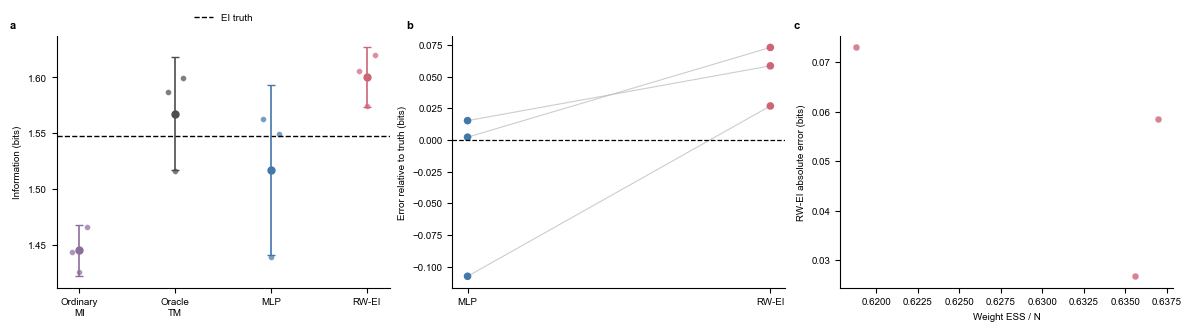

**Smoke 结果解读。** MLP 与 RW-EI 的配对差为 -0.083 bit，90% CI [-0.162, -0.004]，尚未完全落入预注册等价界限（±0.05 bit）。相对数值真值，MLP 的 MAE 为 0.042 bit，RW-EI 为 0.053 bit；普通 MI 的数值真值为 1.425 bit，未加权 TM 均值为 1.445 bit。RW-EI 在 0/3 个 seed 中位于普通 MI 真值 1.425 bit 与 EI 真值 1.547 bit 之间。重加权的平均 ESS/N 为 0.630。Smoke 结果只验证代码链路，正式结论仍应使用 30 个配对 seed 和样本量/相关强度扫描。

In [6]:
figure = plot_comparison(records, SMOKE_CONFIG, output_dir=RESULT_DIR)
display(figure)
plt.close(figure)
display(Markdown(build_interpretation(records, SMOKE_CONFIG)))

## 7. 识别条件与结果边界

直接重加权法可以不拟合 $p(y\mid\boldsymbol{x})$，也不要求 $f$ 线性，但并非无条件成立。它依赖：

- **机制不变性**：观测与输入干预下的 $p(y\mid\boldsymbol{x})$ 相同；
- **可交换性**：不存在同时影响输入与输出、且未被控制的混杂，使观测条件分布可代表干预条件分布；
- **正值性/支持重叠**：若 $q_{\mathrm{do}}(\boldsymbol{x})>0$，则需有 $p_{\mathrm{obs}}(\boldsymbol{x})>0$；
- **可控权重方差**：极小 ESS 表明有限样本结果不可靠；
- **密度比与 TM 近似充分**：两者都会产生有限样本偏差。

因此这里更准确的说法是 **transition-model-free EI estimator**：它绕过动力学回归模型，但仍需要估计输入分布比，并需要明确的因果识别条件。

In [7]:
# 正式实验：优先读取逐 seed 缓存汇总；仅在显式开启时从 notebook 重新运行。
full_records_path = RESULT_DIR / "full_validation_records.json"
if full_records_path.exists():
    payload = json.loads(full_records_path.read_text(encoding="utf-8"))
    full_records = pd.DataFrame(payload["records"])
    full_summary = aggregate_full_validation(full_records)
    full_agreement = summarize_full_agreement(full_records)
    display(full_summary[full_summary["method"] != "reweight_true_tm"][[
        "sweep", "n_samples", "rho", "method_label", "seeds",
        "mean_information_bits", "mean_error_bits", "mae_bits", "estimated_ess_ratio",
    ]].style.format(precision=4))
    display(full_agreement.style.format(precision=4))
    display(Markdown(build_full_interpretation(full_records)))
elif RUN_FULL:
    raise RuntimeError("请运行 exp/reweighted_ei/run_full_validation.py；该入口支持逐 seed 恢复与进度监控。")
else:
    print("尚无全量缓存；RUN_FULL=False。")

,sweep,n_samples,rho,method_label,seeds,mean_information_bits,mean_error_bits,mae_bits,estimated_ess_ratio
0,rho,8000,0.0000,Ordinary MI (observed + TM),30,1.5731,0.0258,0.0259,0.9052
1,rho,8000,0.0000,Oracle samples + TM,30,1.5675,0.0202,0.0215,0.9052
2,rho,8000,0.0000,MLP intervention + TM,30,1.5469,-0.0005,0.0247,0.9052
4,rho,8000,0.0000,RW-EI,30,1.5737,0.0263,0.0263,0.9052
5,rho,8000,0.3000,Ordinary MI (observed + TM),30,1.5180,0.0182,0.0202,0.8002
6,rho,8000,0.3000,Oracle samples + TM,30,1.5675,0.0202,0.0215,0.8002
7,rho,8000,0.3000,MLP intervention + TM,30,1.5500,0.0027,0.0301,0.8002
9,rho,8000,0.3000,RW-EI,30,1.5776,0.0303,0.0303,0.8002
10,rho,8000,0.6000,Ordinary MI (observed + TM),30,1.3825,0.0121,0.0160,0.4824
11,rho,8000,0.6000,Oracle samples + TM,30,1.5675,0.0202,0.0215,0.4824


,sweep,grid_id,n_samples,rho,seeds,paired_mean_difference_bits,paired_90ci_low_bits,paired_90ci_high_bits,equivalent_within_margin,between_truths_rate,reweighted_mean_error_bits,estimated_ess_ratio
0,rho,0,8000,0.0000,30,-0.0268,-0.0374,-0.0162,True,0.0000,0.0263,0.9052
1,rho,1,8000,0.3000,30,-0.0276,-0.0401,-0.0151,True,0.0000,0.0303,0.8002
2,rho,2,8000,0.6000,30,0.0074,-0.0077,0.0224,True,0.2667,0.0149,0.4824
3,rho,3,8000,0.8000,30,0.0840,0.0664,0.1016,False,1.0000,-0.0766,0.2838
4,rho,7,8000,0.1000,30,-0.0309,-0.0426,-0.0192,True,0.0000,0.0291,0.8958
5,rho,8,8000,0.2000,30,-0.0314,-0.0435,-0.0193,True,0.0000,0.0298,0.8616
6,rho,9,8000,0.4000,30,-0.0214,-0.0358,-0.0070,True,0.0000,0.0293,0.7087
7,rho,10,8000,0.5000,30,-0.0096,-0.0248,0.0056,True,0.1667,0.0232,0.6018
8,rho,11,8000,0.7000,30,0.0350,0.0196,0.0504,False,0.5667,-0.0087,0.3685
9,rho,12,8000,0.9000,30,0.1068,0.0817,0.1319,False,1.0000,-0.2428,0.2361


**全量结果解读。** 在样本量扫描中，RW-EI 的 MAE 从 N=1,000 时的 0.035 bit 变化到 N=64,000 时的 0.015 bit。在相关强度扫描中，其 MAE 从 ρ=0.0 时的 0.026 bit 变化到 ρ=0.9 时的 0.243 bit。MLP 与 RW-EI 在 13/17 个条件下通过 ±0.05 bit 的配对等价判据。逐条件的 ESS/N、配对区间及重加权结果落在两个真值之间的比例见正式汇总表。

## 8. 运行时间与计算复杂度

令 $N$ 为观测样本数，$M$ 为干预样本数，$E$ 为 MLP 训练 epoch 数，$P$ 为 MLP 每次前向/反向传播涉及的参数运算规模。本实验两层宽度为 32 的 MLP 有 $P=1185$ 个可训练参数，$E=120$，且 $M=N$。

对于总次数不超过 $d$ 的多项式 TM，具有 $j$ 个前置变量的三角分量包含

$$
K_j=\binom{j+d}{d}
$$

个基函数。加权与未加权最小二乘的主要成本均为

$$
T_{\mathrm{TM}}(N)=\mathcal O\!\left(N\sum_jK_j^2+\sum_jK_j^3\right),\qquad M_{\mathrm{TM}}(N)=\mathcal O(NK_{\max}).
$$

本实验 $d=5$ 且联合变量为 $(X_1,X_2,Y)$，所以最大的 $K_j=\binom{7}{5}=21$；固定维度与阶数时，TM 对 $N$ 近似线性。各路径的渐近成本为：

| 路径 | 主要时间复杂度 | 主要额外存储 |
|---|---|---|
| 普通 MI | $T_{\mathrm{TM}}(N)$ | $\mathcal O(NK_{\max})$ |
| Oracle 采样 + TM | $\mathcal O(MC_f)+T_{\mathrm{TM}}(M)$ | $\mathcal O(MK_{\max})$ |
| MLP 干预 + TM | $\mathcal O(ENP+MP)+T_{\mathrm{TM}}(M)$ | $\mathcal O(P+BK_{\mathrm{net}}+MK_{\max})$ |
| RW-EI | 平均 $\mathcal O(N\log N)+T_{\mathrm{TM}}(N)$ | $\mathcal O(NK_{\max}+N)$ |
| 数值真值求积 | $\mathcal O(GL^2)$ | 分块实现约 $\mathcal O(CL^2)$ |

其中 $C_f$ 是一次已知动力学求值成本，$B$ 是 MLP batch size，$G$ 是输出积分网格数，$L$ 是每个输入轴的求积节点数，$C$ 是输出网格分块大小。kNN 的 $N\log N$ 是低维 cKDTree 的平均复杂度，最坏情况可能退化。

计时采用同一进程的热启动 wall-clock；公共数据生成不计入方法时间。每个 $N\in\{1000,2000,4000,8000,16000,32000,64000\}$ 使用相同 10 个 seed，seed 内随机化方法顺序，报告中位数与四分位区间。实测时间依赖硬件与数值库，适合比较本实现的相对成本，而不是跨机器的绝对基准。

,n_samples,method_label,seeds,median_seconds,q25_seconds,q75_seconds,empirical_scaling_exponent
0,2000,Ordinary MI (observed + TM),10,0.0232,0.0193,0.0353,0.8048
2,2000,MLP intervention + TM,10,0.5569,0.5465,0.6119,0.8363
3,2000,RW-EI,10,0.0518,0.0383,0.0749,0.8107
4,2000,Oracle samples + TM,10,0.0376,0.0288,0.0424,0.6888
5,8000,Ordinary MI (observed + TM),10,0.0832,0.0562,0.1868,0.8048
7,8000,MLP intervention + TM,10,1.6127,1.5894,1.6442,0.8363
8,8000,RW-EI,10,0.1266,0.1167,0.1545,0.8107
9,8000,Oracle samples + TM,10,0.0827,0.0668,0.0988,0.6888
10,32000,Ordinary MI (observed + TM),10,0.2136,0.1871,0.2495,0.8048
12,32000,MLP intervention + TM,10,5.9844,5.9742,6.1145,0.8363


,method_label,stage,median_seconds
0,RW-EI,density_ratio,0.2723
1,RW-EI,tm,0.1861
2,common_data,data_generation,0.0054
3,mlp_tm,intervention_generation,0.0384
4,mlp_tm,mlp_fit,5.7203
5,mlp_tm,tm,0.1963
6,observational_tm,tm,0.2136
7,oracle_tm,tm,0.2336


,median_seconds
method_label,
EI truth quadrature,0.3312
Ordinary MI truth quadrature,0.3513


在 $N=32,000$ 时，RW-EI 相对 MLP 路径快 **12.8 倍**。

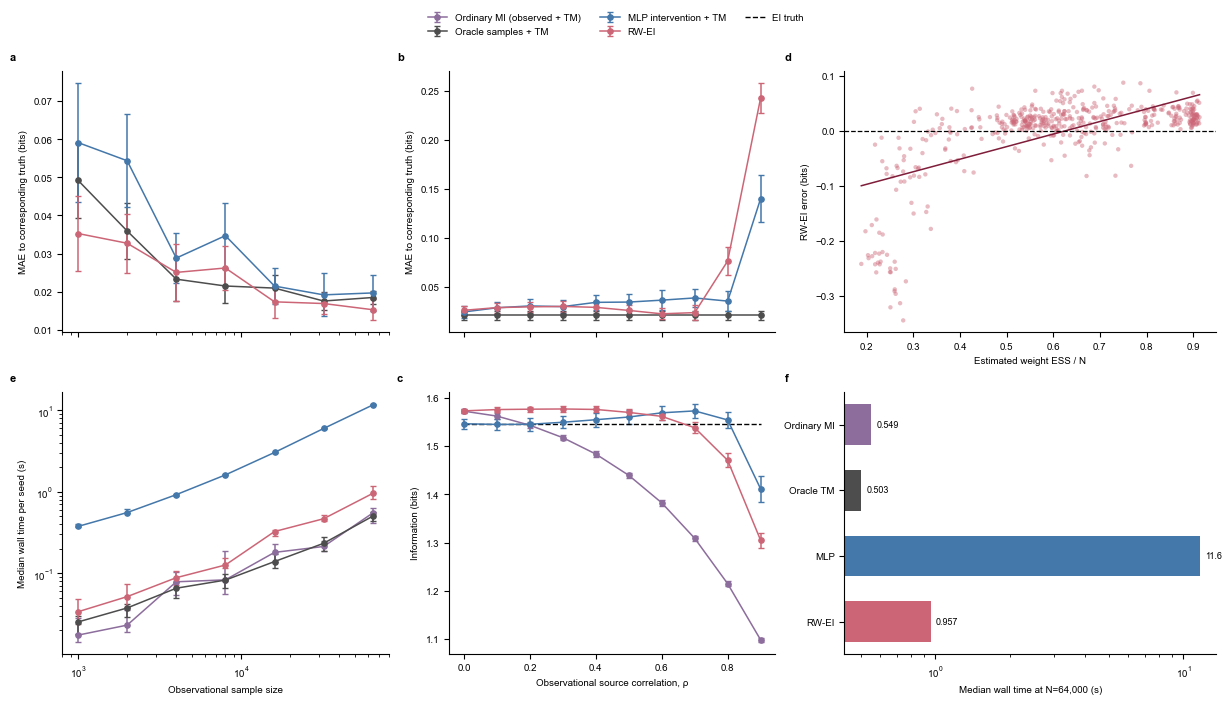

In [8]:
runtime_path = RESULT_DIR / "runtime_benchmark.json"
runtime_payload = json.loads(runtime_path.read_text(encoding="utf-8"))
runtime_records = pd.DataFrame(runtime_payload["records"])
runtime_records["method_label"] = runtime_records["method"].replace({"reweight_knn_tm": "RW-EI"})
runtime_summary = aggregate_runtime_benchmark(runtime_records)
runtime_display = runtime_summary[runtime_summary["method"] != "reweight_true_tm"]
display(runtime_display[[
    "n_samples", "method_label", "seeds", "median_seconds",
    "q25_seconds", "q75_seconds", "empirical_scaling_exponent",
]].style.format(precision=4))

largest_components = (
    runtime_records[(runtime_records["n_samples"] == 32_000) & (runtime_records["stage"] != "total") & (runtime_records["method"] != "reweight_true_tm")]
    .groupby(["method_label", "stage"])["seconds"].median().rename("median_seconds").reset_index()
)
display(largest_components.style.format({"median_seconds": "{:.4f}"}))
truth_runtime = pd.DataFrame(runtime_payload["truth_quadrature"])
display(truth_runtime.groupby("method_label")["seconds"].median().rename("median_seconds").to_frame().style.format(precision=4))

largest = runtime_summary[runtime_summary["n_samples"] == 32_000].set_index("method")
speedup = largest.loc["mlp_tm", "median_seconds"] / largest.loc["reweight_knn_tm", "median_seconds"]
display(Markdown(f"在 $N=32,000$ 时，RW-EI 相对 MLP 路径快 **{speedup:.1f} 倍**。"))
if "full_records" not in globals():
    raise RuntimeError("合并图需要先加载全量验证缓存。")
combined_figure = plot_combined_validation_and_runtime(
    full_records,
    runtime_records,
    output_dir=RESULT_DIR,
)
display(combined_figure)
plt.close(combined_figure)

## 9. 如何形成结论

只有当正式实验同时满足以下证据链，才应声称两种方法在本例上一致且接近原动力学：

1. MLP 与 RW-EI 的配对 90% CI 完全位于 $[-0.05,0.05]$ bit；
2. 两者相对数值真值的 MAE 均足够小，并与 oracle-sample + TM 的估计器误差区分开；
3. 明确报告 RW-EI 是否逐 seed 位于普通 MI 真值和 EI 真值之间；这不是理论必然性质，而是本动力学上的经验检查；
4. 随 $n$ 增大，误差下降或稳定；随 $\rho$ 增大、ESS/N 降低，明确报告 RW-EI 的退化。

这一区分很重要：有限样本中“不一致”可能来自 MLP 近似、密度比估计、TM 读取器或支持重叠，不能仅凭一个最终 EI 数字判断理论恒等式。